In [4]:
import pandas as pd
from colorama.ansi import set_title

df = pd.read_csv("butun-nov-trvz-ehtiyatlar-dt_cd_019.csv", delimiter=",")
df

,Year,Unnamed: 1,İlin əvvəlinə qalıq (ton),İstehsal (ton),İdxal (ton),Ehtiyatların cəmi (ton)
0,2024,NaN,318354.0,1838903.0,80475.0,2237732.0
1,2023,NaN,317893.0,1825592.0,58453.0,2201938.0
2,2022,NaN,313037.0,1823330.0,54638.0,2191005.0
3,2021,NaN,275222.0,1815512.0,63951.0,2154685.0
4,2020,NaN,263922.0,1738860.0,56037.0,2058819.0
5,2019,NaN,219804.0,1714678.0,39806.0,1974288.0
6,2018,NaN,205223.0,1521931.0,36794.0,1763948.0
7,2017,NaN,203338.0,1405619.0,45917.0,1654874.0
8,2016,NaN,189282.0,1270622.0,61184.0,1521088.0
9,2015,NaN,179484.0,1275257.0,41984.0,1496725.0


In [5]:
df = df.drop(columns=['Unnamed: 1'])
df


,Year,İlin əvvəlinə qalıq (ton),İstehsal (ton),İdxal (ton),Ehtiyatların cəmi (ton)
0,2024,318354.0,1838903.0,80475.0,2237732.0
1,2023,317893.0,1825592.0,58453.0,2201938.0
2,2022,313037.0,1823330.0,54638.0,2191005.0
3,2021,275222.0,1815512.0,63951.0,2154685.0
4,2020,263922.0,1738860.0,56037.0,2058819.0
5,2019,219804.0,1714678.0,39806.0,1974288.0
6,2018,205223.0,1521931.0,36794.0,1763948.0
7,2017,203338.0,1405619.0,45917.0,1654874.0
8,2016,189282.0,1270622.0,61184.0,1521088.0
9,2015,179484.0,1275257.0,41984.0,1496725.0


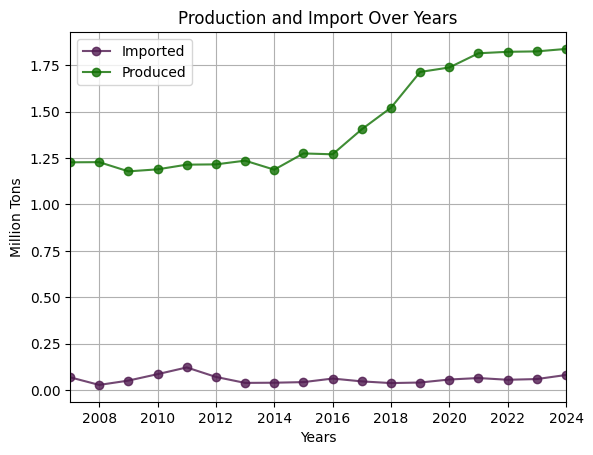

In [47]:
#Line chart
import matplotlib.pyplot as plt
plt.style.use("default")
ax=plt.figure(figsize=(6.4, 4.8))
plt.grid(True)
plt.title("Production and Import Over Years")
plt.plot(df["Year"], df["İdxal (ton)"]/1_000_000,
         marker='o', color=(80/255, 26/255, 80/255, 0.8),
         label="Imported")

plt.plot(df["Year"], df["İstehsal (ton)"]/1_000_000,
         marker='o', color=(16/255, 112/255, 2/255, 0.8),
         label="Produced")
plt.xlabel("Years")
plt.xlim(df["Year"].min(), df["Year"].max())
plt.ylabel("Million Tons")
plt.legend(loc='upper left')

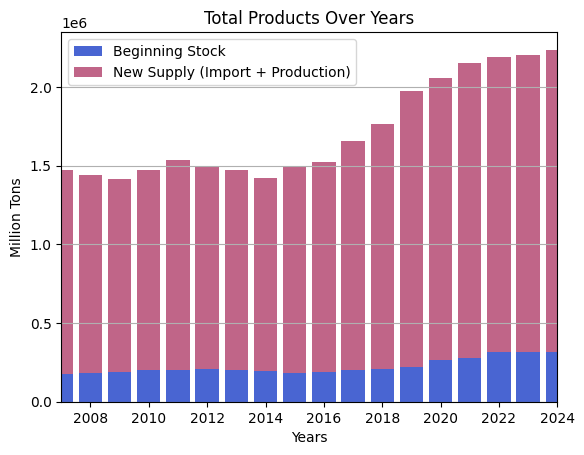

In [77]:
# Stacked Bar Chart (English labels)
plt.figure(figsize=(6.4, 4.8))
plt.title("Total Products Over Years")

base = df["İlin əvvəlinə qalıq (ton)"]
new = df["İdxal (ton)"] + df["İstehsal (ton)"]

plt.bar(df["Year"], base,
        color="#0C32C4", alpha=0.75,
        label="Beginning Stock")

plt.bar(df["Year"], new,
        bottom=base,
        color="#AB3260", alpha=0.75,
        label="New Supply (Import + Production)")

plt.xlabel("Years")
plt.xlim(df["Year"].min(), df["Year"].max())
plt.ylabel("Million Tons")
plt.legend()
plt.grid(axis="y")
plt.show()


In [60]:
#Growth's chart
df["Production_Growth_%"] = df["İstehsal (ton)"].pct_change(periods=-1) * 100
df

,Year,İlin əvvəlinə qalıq (ton),İstehsal (ton),İdxal (ton),Ehtiyatların cəmi (ton),Production_Growth_%
0,2024,318354.0,1838903.0,80475.0,2237732.0,0.729133
1,2023,317893.0,1825592.0,58453.0,2201938.0,0.124059
2,2022,313037.0,1823330.0,54638.0,2191005.0,0.430622
3,2021,275222.0,1815512.0,63951.0,2154685.0,4.408175
4,2020,263922.0,1738860.0,56037.0,2058819.0,1.410294
5,2019,219804.0,1714678.0,39806.0,1974288.0,12.664635
6,2018,205223.0,1521931.0,36794.0,1763948.0,8.274789
7,2017,203338.0,1405619.0,45917.0,1654874.0,10.624482
8,2016,189282.0,1270622.0,61184.0,1521088.0,-0.363456
9,2015,179484.0,1275257.0,41984.0,1496725.0,7.373697


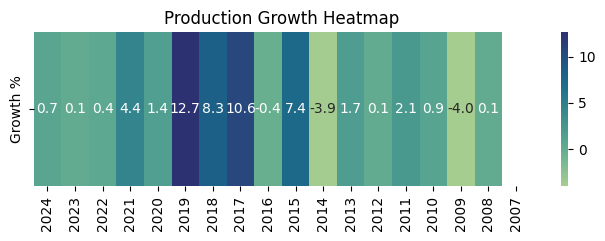

In [76]:
import seaborn as sns

plt.figure(figsize=(8,2))
sns.heatmap([growth], annot=True, fmt=".1f",
            cmap="crest", cbar=True,
            xticklabels=df["Year"],
            yticklabels=["Growth %"])
plt.title("Production Growth Heatmap")
plt.show()
